In [2]:
# ==============================
# DATA MANIPULATION
# ==============================
import pandas as pd
import numpy as np

# ==============================
# VISUALIZATION
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# ==============================
# PREPROCESSING
# ==============================
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# ==============================
# DIMENSIONALITY REDUCTION
# ==============================
from sklearn.decomposition import PCA

# ==============================
# CLUSTERING
# ==============================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==============================
# MACHINE LEARNING
# ==============================
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

# ==============================
# EVALUATION
# ==============================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==============================
# SAVE MODEL
# ==============================
import joblib

# ==============================
# IGNORE WARNING
# ==============================
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("/content/drive/MyDrive/smt 4/raw-measurement-data(1).csv")

df.head()

,Unnamed: 0,temp,rh,pd1,pd2,syl_channel_0,syl_channel_8,syl_channel_1,syl_channel_9,syl_channel_2,...,pla_ref_2_amp,pla_ref_2_ang,pla_sample_3_i,pla_sample_3_q,pla_sample_3_amp,pla_sample_3_ang,pla_ref_3_i,pla_ref_3_q,pla_ref_3_amp,pla_ref_3_ang
0,0,23.307014,60.152590,15134,2990,12973,4737,11832,31858,11935,...,24269.624513,1.347268,319,1121,1165.505041,1.489994,5241,28177,28660.275819,1.536213
1,1,23.333717,60.213627,15146,2993,12957,4737,11816,31859,11919,...,24015.104101,1.347240,317,1109,1153.416664,1.489271,5185,27881,28359.026535,1.536226
2,2,23.307014,60.253300,15136,2991,12943,4737,11802,31859,11904,...,24015.104101,1.347240,317,1109,1153.416664,1.489271,5185,27881,28359.026535,1.536226
3,3,23.320366,60.289920,15178,3001,12930,4737,11789,31859,11891,...,23924.302163,1.347236,317,1104,1148.610030,1.488534,5165,27775,28251.156613,1.536230
4,4,23.320366,60.331120,15539,3100,12917,4737,11777,31859,11879,...,23924.302163,1.347236,317,1104,1148.610030,1.488534,5165,27775,28251.156613,1.536230


In [4]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

(1186151, 53)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186151 entries, 0 to 1186150
Data columns (total 53 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Unnamed: 0        1186151 non-null  int64  
 1   temp              1186151 non-null  float64
 2   rh                1186151 non-null  float64
 3   pd1               1186151 non-null  int64  
 4   pd2               1186151 non-null  int64  
 5   syl_channel_0     1186151 non-null  int64  
 6   syl_channel_8     1186151 non-null  int64  
 7   syl_channel_1     1186151 non-null  int64  
 8   syl_channel_9     1186151 non-null  int64  
 9   syl_channel_2     1186151 non-null  int64  
 10  syl_channel_10    1186151 non-null  int64  
 11  syl_channel_3     1186151 non-null  int64  
 12  syl_channel_11    1186151 non-null  int64  
 13  syl_channel_4     1186151 non-null  int64  
 14  syl_channel_12    1186151 non-null  int64  
 15  syl_channel_5     1186151 non-null 

np.int64(0)

In [5]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [6]:
start_time = pd.Timestamp("2019-12-24 00:00:00")

df["timestamp"] = pd.date_range(
    start=start_time,
    periods=len(df),
    freq="S"
)

df.head()

,temp,rh,pd1,pd2,syl_channel_0,syl_channel_8,syl_channel_1,syl_channel_9,syl_channel_2,syl_channel_10,...,pla_ref_2_ang,pla_sample_3_i,pla_sample_3_q,pla_sample_3_amp,pla_sample_3_ang,pla_ref_3_i,pla_ref_3_q,pla_ref_3_amp,pla_ref_3_ang,timestamp
0,23.307014,60.152590,15134,2990,12973,4737,11832,31858,11935,31898,...,1.347268,319,1121,1165.505041,1.489994,5241,28177,28660.275819,1.536213,2019-12-24 00:00:00
1,23.333717,60.213627,15146,2993,12957,4737,11816,31859,11919,31898,...,1.347240,317,1109,1153.416664,1.489271,5185,27881,28359.026535,1.536226,2019-12-24 00:00:01
2,23.307014,60.253300,15136,2991,12943,4737,11802,31859,11904,31898,...,1.347240,317,1109,1153.416664,1.489271,5185,27881,28359.026535,1.536226,2019-12-24 00:00:02
3,23.320366,60.289920,15178,3001,12930,4737,11789,31859,11891,31898,...,1.347236,317,1104,1148.610030,1.488534,5165,27775,28251.156613,1.536230,2019-12-24 00:00:03
4,23.320366,60.331120,15539,3100,12917,4737,11777,31859,11879,31898,...,1.347236,317,1104,1148.610030,1.488534,5165,27775,28251.156613,1.536230,2019-12-24 00:00:04


In [7]:
df = df.set_index("timestamp")

In [8]:
df_window = df.resample("1min").agg(
    ["mean","std","min","max"]
)

In [9]:
df_window.columns = [
    "_".join(col)
    for col in df_window.columns
]

df_window = df_window.reset_index()

In [10]:
df_window.head()


,timestamp,temp_mean,temp_std,temp_min,temp_max,rh_mean,rh_std,rh_min,rh_max,pd1_mean,...,pla_ref_3_q_min,pla_ref_3_q_max,pla_ref_3_amp_mean,pla_ref_3_amp_std,pla_ref_3_amp_min,pla_ref_3_amp_max,pla_ref_3_ang_mean,pla_ref_3_ang_std,pla_ref_3_ang_min,pla_ref_3_ang_max
0,2019-12-24 00:00:00,23.336254,0.020280,23.293663,23.376442,61.740851,1.214153,59.745174,63.727780,15537.833333,...,27775,28177,28346.516396,44.927257,28251.156613,28660.275819,1.536226,2.319470e-06,1.536213,1.536230
1,2019-12-24 00:01:00,23.405192,0.026709,23.349740,23.461891,65.462094,0.929609,63.700314,66.712440,15604.800000,...,27865,27866,28342.780503,0.177969,28342.747732,28343.730877,1.536226,4.487790e-07,1.536226,1.536228
2,2019-12-24 00:02:00,23.434832,0.023861,23.376442,23.475243,63.475115,1.735208,60.930800,66.474400,15650.866667,...,27865,27865,28342.753827,0.033100,28342.747732,28342.930582,1.536226,2.413566e-06,1.536213,1.536226
3,2019-12-24 00:03:00,23.285561,0.062842,23.165482,23.392464,60.342717,0.249991,59.951170,60.843822,15626.666667,...,27865,27866,28342.995770,0.398021,28342.747732,28343.913721,1.536219,6.403287e-06,1.536213,1.536226
4,2019-12-24 00:04:00,23.052217,0.069841,22.951859,23.178833,61.692353,0.879344,60.614937,63.363087,15412.833333,...,27865,27866,28343.710998,0.410020,28342.747732,28343.913721,1.536215,2.243354e-06,1.536213,1.536226


In [11]:
print(df_window.shape)

(19770, 209)


In [12]:
print("="*60)
print("DATASET SETELAH WINDOW ANALYSIS")
print("="*60)

print("Jumlah Baris :", df_window.shape[0])
print("Jumlah Kolom :", df_window.shape[1])

df_window.head()

DATASET SETELAH WINDOW ANALYSIS
Jumlah Baris : 19770
Jumlah Kolom : 209


,timestamp,temp_mean,temp_std,temp_min,temp_max,rh_mean,rh_std,rh_min,rh_max,pd1_mean,...,pla_ref_3_q_min,pla_ref_3_q_max,pla_ref_3_amp_mean,pla_ref_3_amp_std,pla_ref_3_amp_min,pla_ref_3_amp_max,pla_ref_3_ang_mean,pla_ref_3_ang_std,pla_ref_3_ang_min,pla_ref_3_ang_max
0,2019-12-24 00:00:00,23.336254,0.020280,23.293663,23.376442,61.740851,1.214153,59.745174,63.727780,15537.833333,...,27775,28177,28346.516396,44.927257,28251.156613,28660.275819,1.536226,2.319470e-06,1.536213,1.536230
1,2019-12-24 00:01:00,23.405192,0.026709,23.349740,23.461891,65.462094,0.929609,63.700314,66.712440,15604.800000,...,27865,27866,28342.780503,0.177969,28342.747732,28343.730877,1.536226,4.487790e-07,1.536226,1.536228
2,2019-12-24 00:02:00,23.434832,0.023861,23.376442,23.475243,63.475115,1.735208,60.930800,66.474400,15650.866667,...,27865,27865,28342.753827,0.033100,28342.747732,28342.930582,1.536226,2.413566e-06,1.536213,1.536226
3,2019-12-24 00:03:00,23.285561,0.062842,23.165482,23.392464,60.342717,0.249991,59.951170,60.843822,15626.666667,...,27865,27866,28342.995770,0.398021,28342.747732,28343.913721,1.536219,6.403287e-06,1.536213,1.536226
4,2019-12-24 00:04:00,23.052217,0.069841,22.951859,23.178833,61.692353,0.879344,60.614937,63.363087,15412.833333,...,27865,27866,28343.710998,0.410020,28342.747732,28343.913721,1.536215,2.243354e-06,1.536213,1.536226


In [13]:
df_window.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,19770,2019-12-30 20:44:30,2019-12-24 00:00:00,2019-12-27 10:22:15,2019-12-30 20:44:30,2020-01-03 07:06:45,2020-01-06 17:29:00,NaN
temp_mean,19770.0,17.872142,10.1402,11.21514,22.393494,22.857353,23.72901,5.691452
temp_std,19770.0,0.026846,0.008548,0.014394,0.019282,0.027103,0.230148,0.025369
temp_min,19770.0,17.81947,10.104904,11.167698,22.356377,22.810333,23.675514,5.690947
temp_max,19770.0,17.924875,10.174335,11.266499,22.428474,22.909134,23.774323,5.692176
...,...,...,...,...,...,...,...,...
pla_ref_3_amp_max,19770.0,28346.888161,28342.564916,28343.730877,28344.531219,28350.978555,28660.275819,4.204403
pla_ref_3_ang_mean,19770.0,1.536225,1.536196,1.536215,1.536228,1.536232,1.536249,0.000011
pla_ref_3_ang_std,19770.0,0.000001,0.0,0.0,0.0,0.000001,0.000009,0.000001
pla_ref_3_ang_min,19770.0,1.536224,1.536192,1.536215,1.536226,1.53623,1.536249,0.000012


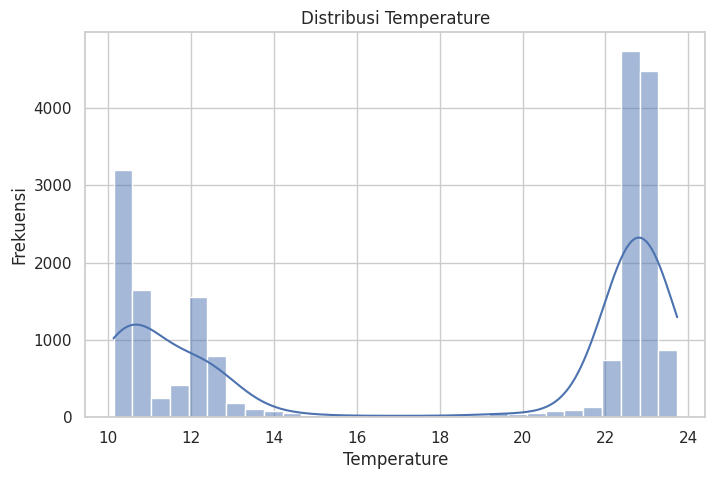

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_window["temp_mean"],
    bins=30,
    kde=True
)

plt.title("Distribusi Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frekuensi")

plt.show()

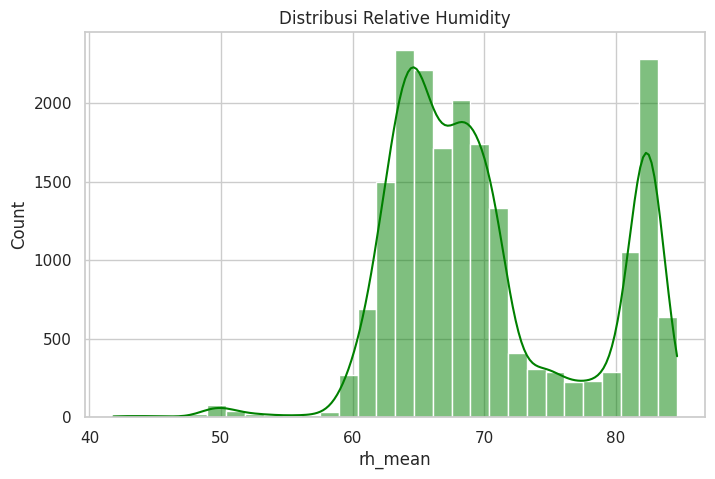

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_window["rh_mean"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribusi Relative Humidity")

plt.show()

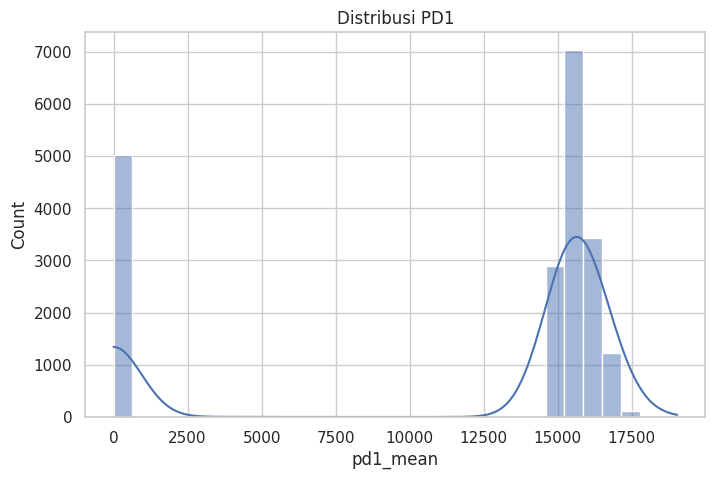

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_window["pd1_mean"],
    bins=30,
    kde=True
)

plt.title("Distribusi PD1")

plt.show()

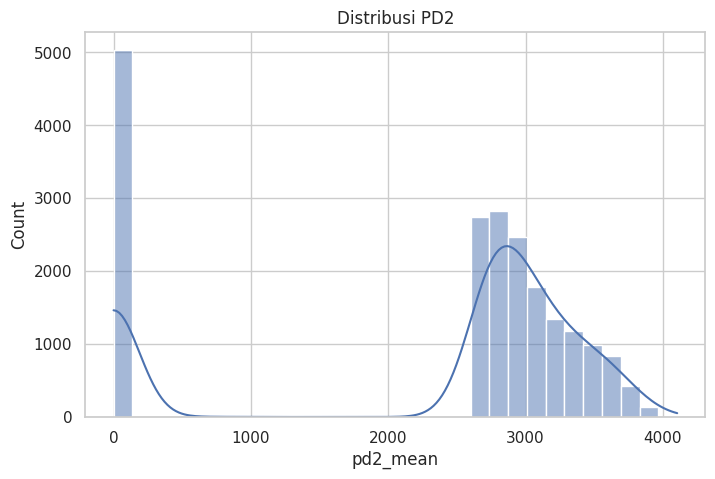

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_window["pd2_mean"],
    bins=30,
    kde=True
)

plt.title("Distribusi PD2")

plt.show()

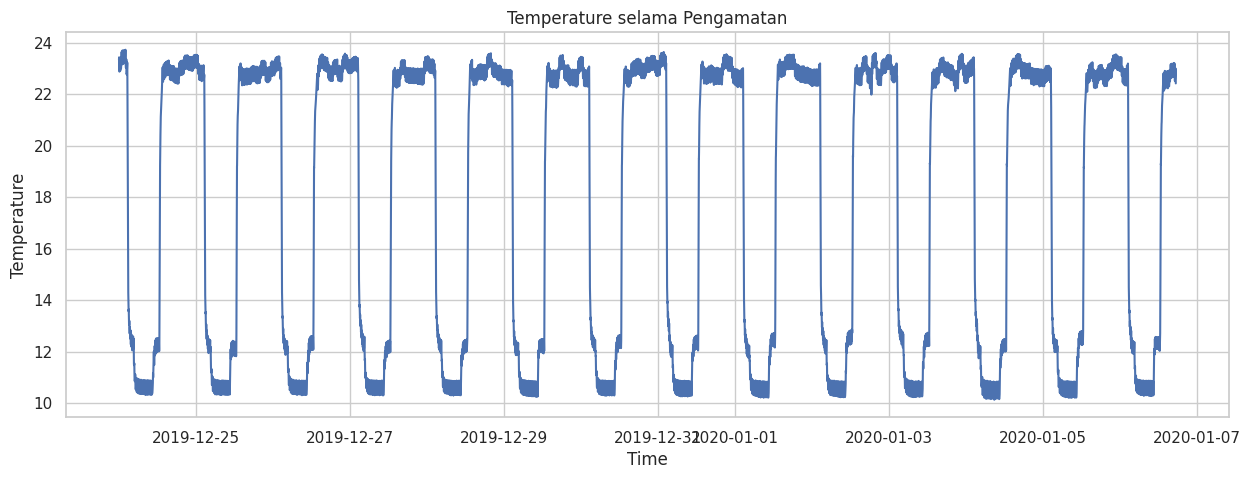

In [18]:
plt.figure(figsize=(15,5))

plt.plot(
    df_window["timestamp"],
    df_window["temp_mean"]
)

plt.title("Temperature selama Pengamatan")

plt.xlabel("Time")

plt.ylabel("Temperature")

plt.show()

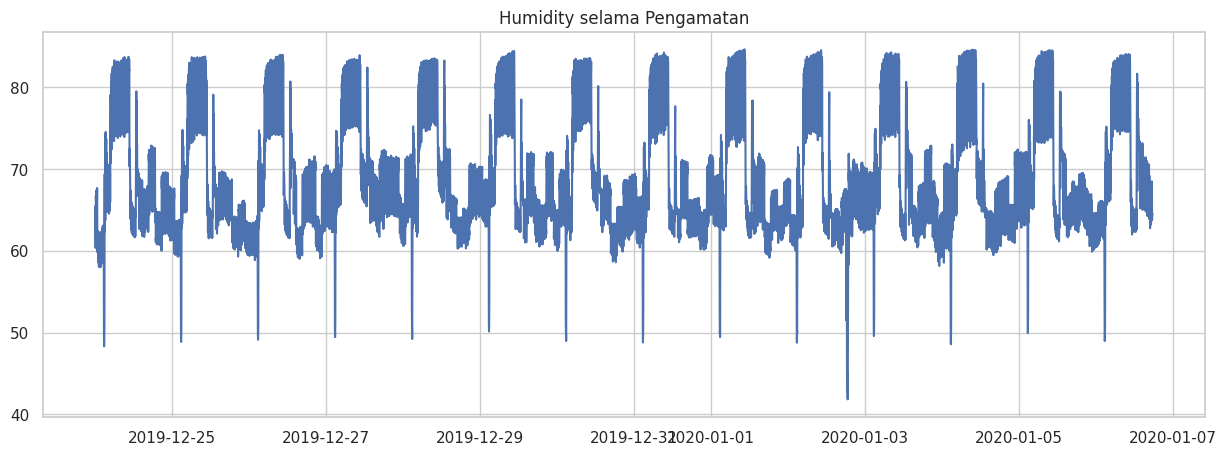

In [19]:
plt.figure(figsize=(15,5))

plt.plot(
    df_window["timestamp"],
    df_window["rh_mean"]
)

plt.title("Humidity selama Pengamatan")

plt.show()

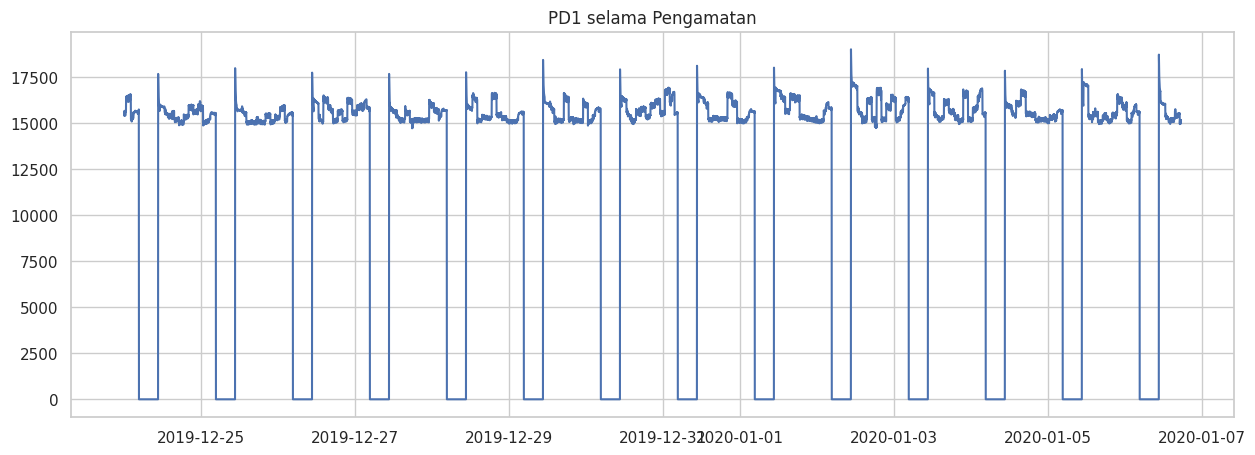

In [20]:
plt.figure(figsize=(15,5))

plt.plot(
    df_window["timestamp"],
    df_window["pd1_mean"]
)

plt.title("PD1 selama Pengamatan")

plt.show()

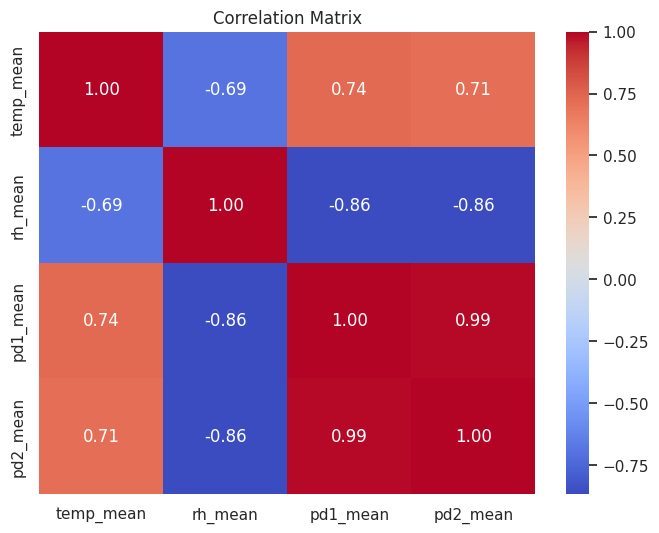

In [21]:
selected = [

    "temp_mean",

    "rh_mean",

    "pd1_mean",

    "pd2_mean"

]

corr = df_window[selected].corr()

plt.figure(figsize=(8,6))

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Matrix")

plt.show()

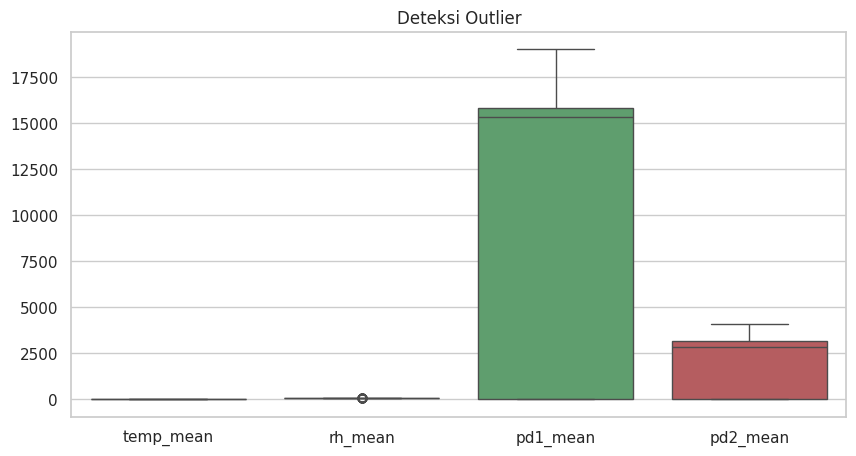

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(

    data=df_window[

        [

            "temp_mean",

            "rh_mean",

            "pd1_mean",

            "pd2_mean"

        ]

    ]

)

plt.title("Deteksi Outlier")

plt.show()

In [23]:
spectral = [

col

for col in df_window.columns

if "syl_channel" in col

and "_mean" in col

]

In [24]:
df_window[spectral].head()

,syl_channel_0_mean,syl_channel_8_mean,syl_channel_1_mean,syl_channel_9_mean,syl_channel_2_mean,syl_channel_10_mean,syl_channel_3_mean,syl_channel_11_mean,syl_channel_4_mean,syl_channel_12_mean,syl_channel_5_mean,syl_channel_13_mean,syl_channel_6_mean,syl_channel_14_mean,syl_channel_7_mean,syl_channel_15_mean
0,12776.166667,4732.266667,11639.100000,31860.016667,11740.550000,31899.350000,10399.400000,-11192.800000,13460.966667,-17380.783333,717.583333,-19234.166667,32404.950000,-32641.000000,12430.250000,31733.533333
1,12618.233333,4723.266667,11485.100000,31860.750000,11586.150000,31900.183333,10249.533333,-12170.483333,13300.733333,-16673.250000,716.933333,-18908.683333,32407.866667,-32640.683333,12272.816667,31734.350000
2,12562.533333,4713.266667,11431.733333,31860.750000,11532.083333,31900.433333,10196.416667,-12958.333333,13244.183333,-16277.133333,691.066667,-18716.200000,32409.000000,-32640.316667,12217.183333,31734.166667
3,12560.450000,4698.183333,11430.333333,31861.366667,11528.983333,31900.833333,10192.250000,-12741.566667,13241.450000,-15944.683333,667.600000,-19242.750000,32409.083333,-32640.900000,12213.950000,31735.766667
4,12576.416667,4680.083333,11444.333333,31862.183333,11542.850000,31901.516667,10205.516667,-13522.283333,13255.550000,-15545.183333,674.283333,-19094.416667,32409.000000,-32641.000000,12227.883333,31737.600000


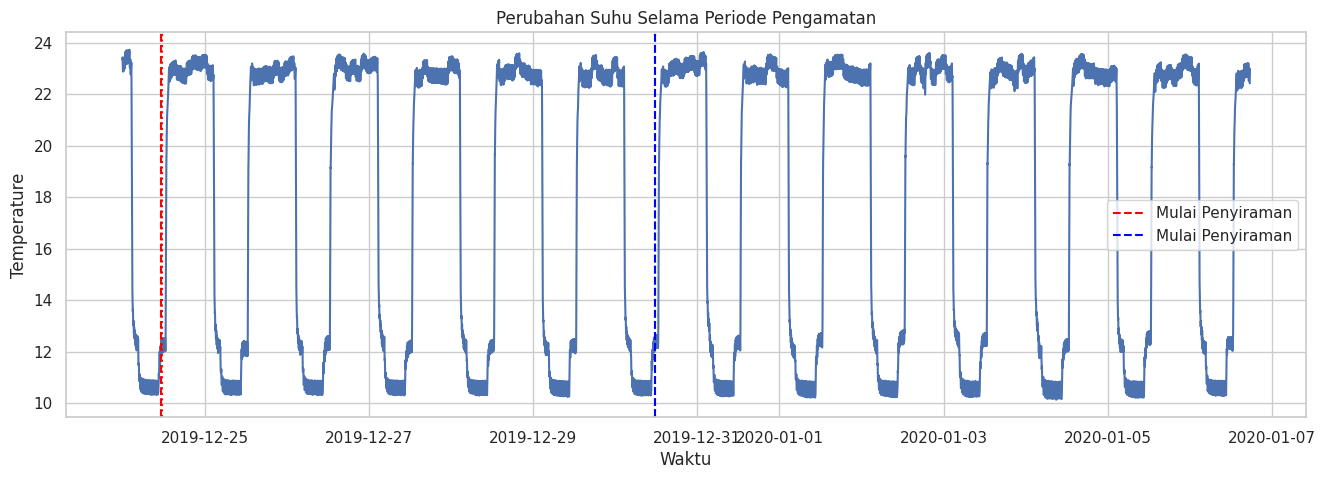

In [25]:
plt.figure(figsize=(16,5))

plt.plot(df_window["timestamp"], df_window["temp_mean"])

plt.axvline(pd.Timestamp("2019-12-24 11:12"), color="red", linestyle="--", label="Mulai Penyiraman")
plt.axvline(pd.Timestamp("2019-12-24 11:25"), color="red", linestyle=":")
plt.axvline(pd.Timestamp("2019-12-30 11:30"), color="blue", linestyle="--", label="Mulai Penyiraman")
plt.axvline(pd.Timestamp("2019-12-30 11:45"), color="blue", linestyle=":")

plt.legend()
plt.title("Perubahan Suhu Selama Periode Pengamatan")
plt.xlabel("Waktu")
plt.ylabel("Temperature")
plt.show()

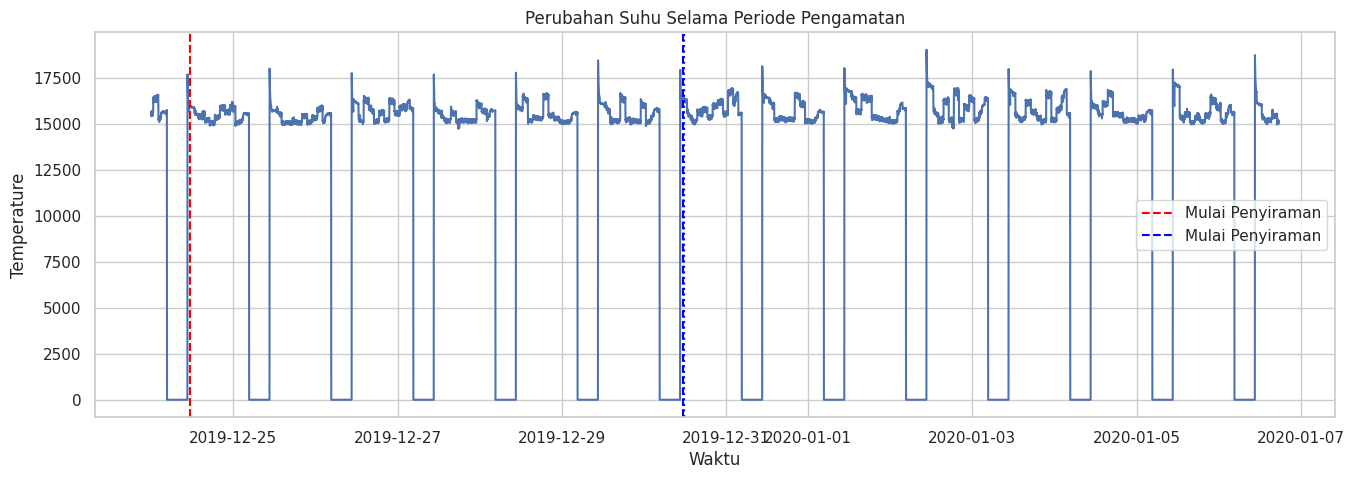

In [26]:
plt.figure(figsize=(16,5))

plt.plot(df_window["timestamp"], df_window["pd1_mean"])

plt.axvline(pd.Timestamp("2019-12-24 11:12"), color="red", linestyle="--", label="Mulai Penyiraman")
plt.axvline(pd.Timestamp("2019-12-24 11:25"), color="red", linestyle=":")
plt.axvline(pd.Timestamp("2019-12-30 11:30"), color="blue", linestyle="--", label="Mulai Penyiraman")
plt.axvline(pd.Timestamp("2019-12-30 11:45"), color="blue", linestyle=":")

plt.legend()
plt.title("Perubahan Suhu Selama Periode Pengamatan")
plt.xlabel("Waktu")
plt.ylabel("Temperature")
plt.show()

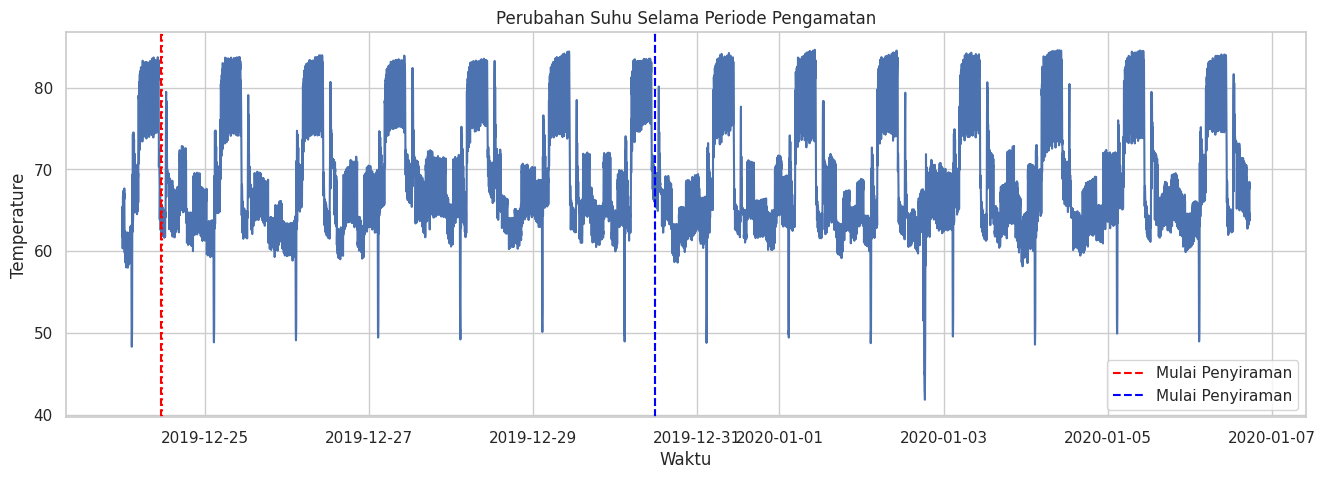

In [27]:
plt.figure(figsize=(16,5))

plt.plot(df_window["timestamp"], df_window["rh_mean"])

plt.axvline(pd.Timestamp("2019-12-24 11:12"), color="red", linestyle="--", label="Mulai Penyiraman")
plt.axvline(pd.Timestamp("2019-12-24 11:25"), color="red", linestyle=":")
plt.axvline(pd.Timestamp("2019-12-30 11:30"), color="blue", linestyle="--", label="Mulai Penyiraman")
plt.axvline(pd.Timestamp("2019-12-30 11:45"), color="blue", linestyle=":")

plt.legend()
plt.title("Perubahan Suhu Selama Periode Pengamatan")
plt.xlabel("Waktu")
plt.ylabel("Temperature")
plt.show()

In [28]:
df_feature = df_window.copy()

In [29]:
# ===============================
# Spectral Sensor
# ===============================

syl_cols = [
    col
    for col in df_feature.columns
    if "syl_channel" in col and "_mean" in col
]

# ===============================
# PLA Sample Amplitude
# ===============================

pla_sample_amp = [
    col
    for col in df_feature.columns
    if "pla_sample" in col and "_amp_mean" in col
]

# ===============================
# PLA Reference Amplitude
# ===============================

pla_ref_amp = [
    col
    for col in df_feature.columns
    if "pla_ref" in col and "_amp_mean" in col
]

In [30]:
df_feature["spectral_mean"] = df_feature[syl_cols].mean(axis=1)

In [31]:
df_feature["spectral_std"] = df_feature[syl_cols].std(axis=1)

In [32]:
df_feature["spectral_max"] = df_feature[syl_cols].max(axis=1)

In [33]:
df_feature["spectral_min"] = df_feature[syl_cols].min(axis=1)

In [34]:
df_feature["pla_sample_mean"] = df_feature[pla_sample_amp].mean(axis=1)

In [35]:
df_feature["pla_ref_mean"] = df_feature[pla_ref_amp].mean(axis=1)

In [36]:
df_feature["pla_difference"] = (
    df_feature["pla_sample_mean"]
    -
    df_feature["pla_ref_mean"]
)

In [37]:
df_feature["temp_rh_index"] = (
    df_feature["temp_mean"]
    *
    df_feature["rh_mean"]
)

In [38]:
df_feature["temp_range"] = (
    df_feature["temp_max"]
    -
    df_feature["temp_min"]
)

In [39]:
df_feature["rh_range"] = (
    df_feature["rh_max"]
    -
    df_feature["rh_min"]
)

In [40]:
df_feature["pd_difference"] = (
    df_feature["pd1_mean"]
    -
    df_feature["pd2_mean"]
)

In [41]:
df_feature.head()

,timestamp,temp_mean,temp_std,temp_min,temp_max,rh_mean,rh_std,rh_min,rh_max,pd1_mean,...,spectral_std,spectral_max,spectral_min,pla_sample_mean,pla_ref_mean,pla_difference,temp_rh_index,temp_range,rh_range,pd_difference
0,2019-12-24 00:00:00,23.336254,0.020280,23.293663,23.376442,61.740851,1.214153,59.745174,63.727780,15537.833333,...,19788.589514,32404.950000,-32641.000000,3048.834332,21549.529358,-18500.695026,1440.800195,0.082779,3.982606,12438.083333
1,2019-12-24 00:01:00,23.405192,0.026709,23.349740,23.461891,65.462094,0.929609,63.700314,66.712440,15604.800000,...,19751.329398,32407.866667,-32640.683333,3047.115179,21546.970752,-18499.855573,1532.152882,0.112151,3.012126,12484.283333
2,2019-12-24 00:02:00,23.434832,0.023861,23.376442,23.475243,63.475115,1.735208,60.930800,66.474400,15650.866667,...,19751.877639,32409.000000,-32640.316667,3046.197103,21546.906606,-18500.709502,1487.528684,0.098801,5.543600,12514.366667
3,2019-12-24 00:03:00,23.285561,0.062842,23.165482,23.392464,60.342717,0.249991,59.951170,60.843822,15626.666667,...,19758.323485,32409.083333,-32640.900000,3044.675206,21547.307479,-18502.632272,1405.114013,0.226982,0.892652,12496.083333
4,2019-12-24 00:04:00,23.052217,0.069841,22.951859,23.178833,61.692353,0.879344,60.614937,63.363087,15412.833333,...,19769.675117,32409.000000,-32641.000000,3041.932595,21547.717361,-18505.784766,1422.145497,0.226974,2.748150,12344.833333


In [42]:
print(df_feature.shape)

(19770, 220)


In [43]:
df_feature.columns

Index(['timestamp', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'rh_mean',
       'rh_std', 'rh_min', 'rh_max', 'pd1_mean',
       ...
       'spectral_std', 'spectral_max', 'spectral_min', 'pla_sample_mean',
       'pla_ref_mean', 'pla_difference', 'temp_rh_index', 'temp_range',
       'rh_range', 'pd_difference'],
      dtype='object', length=220)

In [44]:
df_feature.isnull().sum().sort_values(ascending=False).head(20)

,0
timestamp,0
temp_mean,0
temp_std,0
temp_min,0
temp_max,0
rh_mean,0
rh_std,0
rh_min,0
rh_max,0
pd1_mean,0


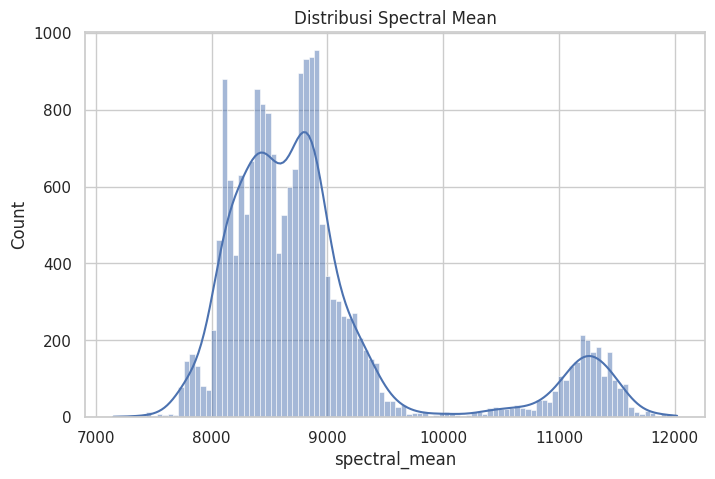

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_feature["spectral_mean"],
    kde=True
)

plt.title("Distribusi Spectral Mean")

plt.show()

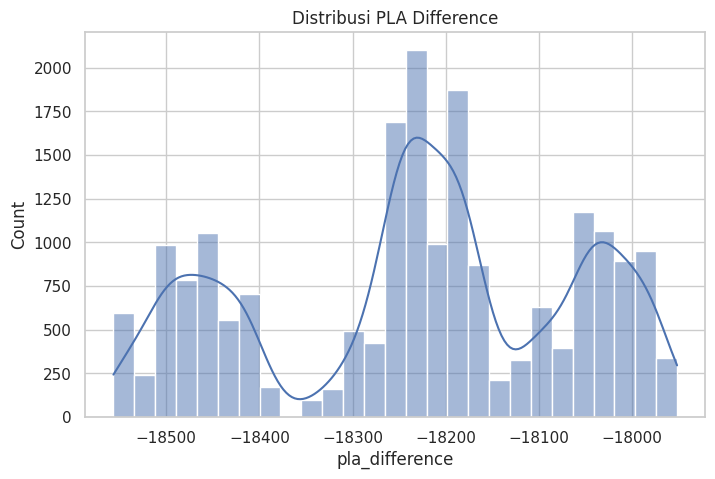

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_feature["pla_difference"],
    kde=True
)

plt.title("Distribusi PLA Difference")

plt.show()

In [47]:
selected_features = [
    "temp_mean",
    "rh_mean",
    "pd1_mean",
    "pd2_mean",
    "spectral_mean",
    "spectral_std",
    "pla_difference",
    "temp_rh_index",
    "temp_range",
    "rh_range"
]

ml_dataset = df_feature[selected_features].copy()

Feature Selection

In [48]:
selected_features = [

    # Environmental
    "temp_mean",
    "rh_mean",
    "pd1_mean",
    "pd2_mean",

    # Spectral
    "spectral_mean",
    "spectral_std",

    # PLA
    "pla_difference",

    # Engineered
    "temp_rh_index",
    "temp_range",
    "rh_range"

]

In [49]:
X = df_feature[selected_features].copy()

X.head()

,temp_mean,rh_mean,pd1_mean,pd2_mean,spectral_mean,spectral_std,pla_difference,temp_rh_index,temp_range,rh_range
0,23.336254,61.740851,15537.833333,3099.750000,7834.086458,19788.589514,-18500.695026,1440.800195,0.082779,3.982606
1,23.405192,65.462094,15604.800000,3120.516667,7778.926042,19751.329398,-18499.855573,1532.152882,0.112151,3.012126
2,23.434832,63.475115,15650.866667,3136.500000,7743.802083,19751.877639,-18500.709502,1487.528684,0.098801,5.543600
3,23.285561,60.342717,15626.666667,3130.583333,7741.896875,19758.323485,-18502.632272,1405.114013,0.226982,0.892652
4,23.052217,61.692353,15412.833333,3068.000000,7732.145833,19769.675117,-18505.784766,1422.145497,0.226974,2.748150


In [50]:
print("Jumlah Data :", X.shape[0])
print("Jumlah Feature :", X.shape[1])

Jumlah Data : 19770
Jumlah Feature : 10


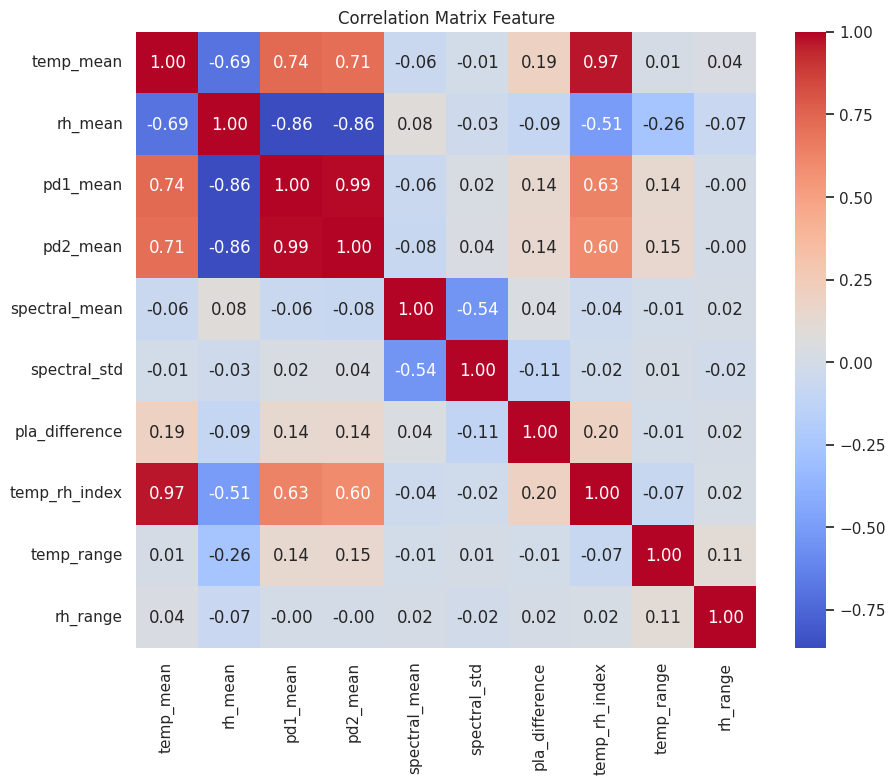

In [51]:
plt.figure(figsize=(10,8))

corr = X.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Feature")

plt.show()

In [52]:
corr_matrix = X.corr().abs()

corr_matrix.head()

,temp_mean,rh_mean,pd1_mean,pd2_mean,spectral_mean,spectral_std,pla_difference,temp_rh_index,temp_range,rh_range
temp_mean,1.000000,0.691043,0.735093,0.710190,0.056647,0.010865,0.191868,0.970144,0.014539,0.036612
rh_mean,0.691043,1.000000,0.864688,0.863047,0.084280,0.033553,0.089949,0.506386,0.264064,0.065942
pd1_mean,0.735093,0.864688,1.000000,0.990254,0.063035,0.024025,0.138749,0.630109,0.139860,0.000488
pd2_mean,0.710190,0.863047,0.990254,1.000000,0.076939,0.035985,0.140979,0.599054,0.145203,0.000371
spectral_mean,0.056647,0.084280,0.063035,0.076939,1.000000,0.542197,0.043512,0.037350,0.007065,0.016165


In [53]:
import numpy as np

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [54]:
0.95

0.95

In [55]:
to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Feature yang akan dihapus:")
print(to_drop)

Feature yang akan dihapus:
['pd2_mean', 'temp_rh_index']


In [56]:
X_filtered = X.drop(columns=to_drop)

X_filtered.head()

,temp_mean,rh_mean,pd1_mean,spectral_mean,spectral_std,pla_difference,temp_range,rh_range
0,23.336254,61.740851,15537.833333,7834.086458,19788.589514,-18500.695026,0.082779,3.982606
1,23.405192,65.462094,15604.800000,7778.926042,19751.329398,-18499.855573,0.112151,3.012126
2,23.434832,63.475115,15650.866667,7743.802083,19751.877639,-18500.709502,0.098801,5.543600
3,23.285561,60.342717,15626.666667,7741.896875,19758.323485,-18502.632272,0.226982,0.892652
4,23.052217,61.692353,15412.833333,7732.145833,19769.675117,-18505.784766,0.226974,2.748150


In [57]:
print(X.shape)

print(X_filtered.shape)

(19770, 10)
(19770, 8)


In [58]:
from sklearn.feature_selection import VarianceThreshold

In [59]:
selector = VarianceThreshold(
    threshold=0.01
)

X_variance = selector.fit_transform(X_filtered)

In [60]:
selected_columns = X_filtered.columns[
    selector.get_support()
]

selected_columns

Index(['temp_mean', 'rh_mean', 'pd1_mean', 'spectral_mean', 'spectral_std',
       'pla_difference', 'rh_range'],
      dtype='object')

In [61]:
X_selected = pd.DataFrame(
    X_variance,
    columns=selected_columns
)

X_selected.head()
print(X_selected.shape)

(19770, 7)


In [62]:
from sklearn.preprocessing import StandardScaler

In [64]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_selected.columns
)

X_scaled.head()

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_selected.columns
)

X_scaled.head()



,temp_mean,rh_mean,pd1_mean,spectral_mean,spectral_std,pla_difference,rh_range
0,0.960080,-1.128572,0.559697,-1.172002,1.843463,-1.610148,2.441194
1,0.972193,-0.626161,0.569466,-1.232203,1.771172,-1.605117,1.602743
2,0.977401,-0.894426,0.576186,-1.270536,1.772236,-1.610235,3.789823
3,0.951173,-1.317337,0.572656,-1.272615,1.784742,-1.621759,-0.228388
4,0.910173,-1.135120,0.541463,-1.283257,1.806766,-1.640653,1.374680


In [65]:
X_scaled.describe()

,temp_mean,rh_mean,pd1_mean,spectral_mean,spectral_std,pla_difference,rh_range
count,1.977000e+04,1.977000e+04,1.977000e+04,1.977000e+04,1.977000e+04,1.977000e+04,1.977000e+04
mean,-7.791890e-16,2.070170e-16,6.469281e-17,-8.596956e-16,-9.660793e-16,-2.760227e-16,2.623653e-17
std,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00
min,-1.358553e+00,-3.817093e+00,-1.706908e+00,-1.916057e+00,-2.749691e+00,-1.944933e+00,-9.508244e-01
25%,-1.169679e+00,-7.394464e-01,-1.706908e+00,-6.023908e-01,-7.999680e-01,-9.999441e-01,-5.685113e-01
50%,7.944309e-01,-2.556584e-01,5.305160e-01,-2.283065e-01,-1.220208e-01,4.652269e-02,-3.259403e-01
75%,8.759340e-01,6.474865e-01,6.034592e-01,9.091939e-02,8.631600e-01,8.510574e-01,1.209673e-01
max,1.029090e+00,1.964572e+00,1.069524e+00,3.395761e+00,3.565688e+00,1.679157e+00,1.000171e+01


CELL 13 — Principal Component Analysis

In [66]:
from sklearn.decomposition import PCA

In [67]:
pca = PCA()

pca.fit(X_scaled)

PCA()

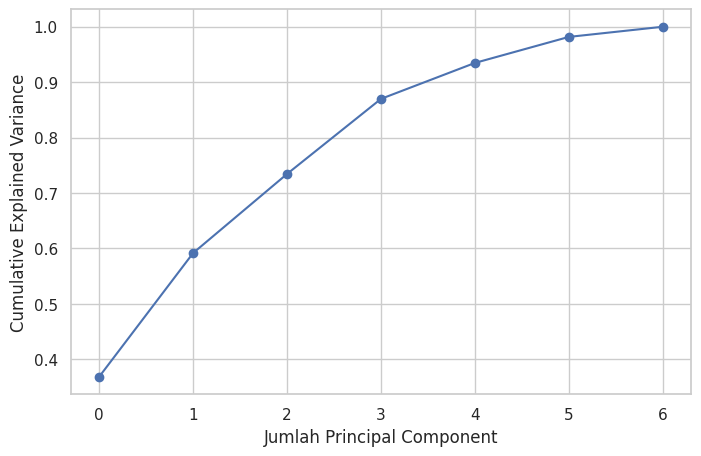

In [69]:
plt.figure(figsize=(8,5))

plt.plot(

    np.cumsum(
        pca.explained_variance_ratio_
    ),

    marker="o"

)

plt.xlabel("Jumlah Principal Component")

plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [70]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

In [71]:
X_pca = pd.DataFrame(

    X_pca,

    columns=[

        "PC1",

        "PC2"

    ]

)

X_pca.head()

,PC1,PC2
0,1.513076,2.233067
1,1.209126,2.264465
2,1.452851,2.183333
3,1.530357,2.394236
4,1.442989,2.345455


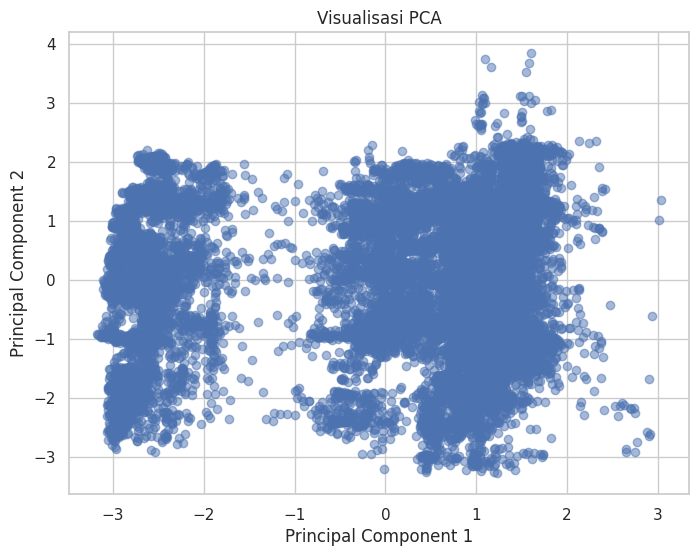

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(

    X_pca["PC1"],

    X_pca["PC2"],

    alpha=0.5

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Visualisasi PCA")

plt.show()

In [73]:
explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,Principal Component,Explained Variance,Cumulative
0,PC1,0.368336,0.368336
1,PC2,0.223277,0.591613


In [74]:
print(f"PC1 menjelaskan {pca.explained_variance_ratio_[0]*100:.2f}% variasi data")
print(f"PC2 menjelaskan {pca.explained_variance_ratio_[1]*100:.2f}% variasi data")

PC1 menjelaskan 36.83% variasi data
PC2 menjelaskan 22.33% variasi data


In [75]:
print("Jumlah Feature Awal :", X_selected.shape[1])
print("Jumlah Komponen PCA :", X_pca.shape[1])

Jumlah Feature Awal : 7
Jumlah Komponen PCA : 2


In [76]:
print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)

Explained Variance Ratio
[0.36833596 0.22327712]


**CELL 14 — Menentukan Nilai K dengan Elbow Method**
Tujuan

Mengukur Inertia (WCSS - Within Cluster Sum of Squares) untuk berbagai jumlah cluster.

Semakin kecil inertia, semakin baik. Namun kita mencari titik siku (elbow), bukan nilai inertia terkecil.


In [77]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [78]:
inertia = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

Kenapa n_init=10?

Agar K-Means dijalankan 10 kali dengan centroid awal berbeda, kemudian dipilih hasil terbaik. Ini juga menghindari warning pada versi terbaru scikit-learn.

In [79]:
elbow_df = pd.DataFrame({
    "Jumlah Cluster": list(K),
    "Inertia": inertia
})

elbow_df

,Jumlah Cluster,Inertia
0,2,92290.470147
1,3,74588.527414
2,4,65396.881193
3,5,56879.623132
4,6,50968.042920
5,7,43341.299118
6,8,40009.652615
7,9,36935.616950
8,10,34329.902182


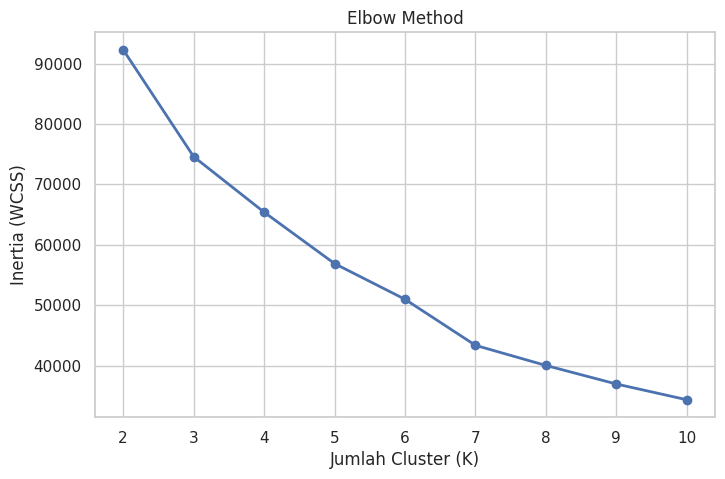

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o',
    linewidth=2
)

plt.xticks(K)

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

**CELL 15 — Menghitung Penurunan Inertia**

In [81]:
elbow_df["Selisih"] = elbow_df["Inertia"].diff(-1).abs()

elbow_df

,Jumlah Cluster,Inertia,Selisih
0,2,92290.470147,17701.942733
1,3,74588.527414,9191.646221
2,4,65396.881193,8517.258061
3,5,56879.623132,5911.580212
4,6,50968.042920,7626.743803
5,7,43341.299118,3331.646503
6,8,40009.652615,3074.035665
7,9,36935.616950,2605.714768
8,10,34329.902182,NaN


**CELL 15 — Silhouette Score
Tujuan**

Silhouette Score digunakan untuk mengukur seberapa baik setiap data berada di dalam clusternya dibandingkan dengan cluster lain.

Nilai Silhouette berada pada rentang:

Nilai	Interpretasi
0.71 – 1.00	Struktur cluster sangat baik
0.51 – 0.70	Struktur cluster baik
0.26 – 0.50	Struktur cluster cukup
0.00 – 0.25	Cluster lemah
< 0	Banyak data salah cluster

Semakin mendekati 1, semakin baik kualitas clustering.

In [82]:
from sklearn.metrics import silhouette_score

In [83]:
silhouette_scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

In [84]:
silhouette_df = pd.DataFrame({

    "Jumlah Cluster": list(K),
    "Silhouette Score": silhouette_scores

})

silhouette_df

,Jumlah Cluster,Silhouette Score
0,2,0.379982
1,3,0.294425
2,4,0.307347
3,5,0.326293
4,6,0.319511
5,7,0.335772
6,8,0.340825
7,9,0.347900
8,10,0.349484


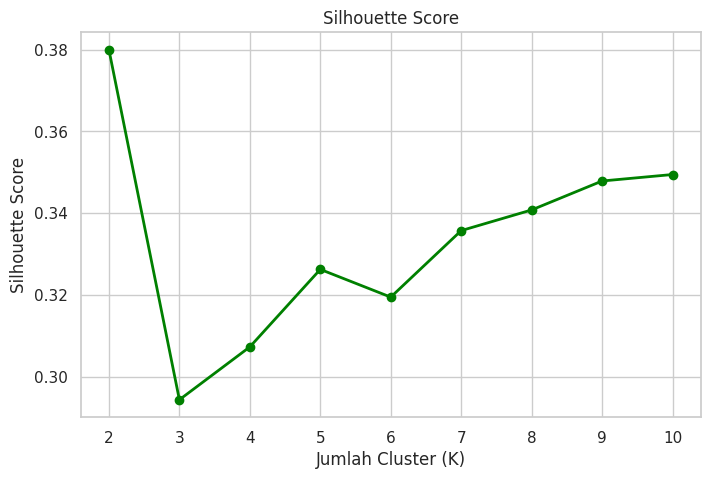

In [85]:
plt.figure(figsize=(8,5))

plt.plot(

    K,

    silhouette_scores,

    marker="o",

    linewidth=2,

    color="green"

)

plt.xticks(K)

plt.xlabel("Jumlah Cluster (K)")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score")

plt.grid(True)

plt.show()

In [86]:
best_k = silhouette_df.loc[
    silhouette_df["Silhouette Score"].idxmax(),
    "Jumlah Cluster"
]

best_score = silhouette_df["Silhouette Score"].max()

print(f"K Terbaik : {best_k}")
print(f"Silhouette Score : {best_score:.4f}")

K Terbaik : 2
Silhouette Score : 0.3800


In [87]:
evaluation_df = elbow_df.copy()

evaluation_df["Silhouette Score"] = silhouette_scores

evaluation_df

,Jumlah Cluster,Inertia,Selisih,Silhouette Score
0,2,92290.470147,17701.942733,0.379982
1,3,74588.527414,9191.646221,0.294425
2,4,65396.881193,8517.258061,0.307347
3,5,56879.623132,5911.580212,0.326293
4,6,50968.042920,7626.743803,0.319511
5,7,43341.299118,3331.646503,0.335772
6,8,40009.652615,3074.035665,0.340825
7,9,36935.616950,2605.714768,0.347900
8,10,34329.902182,NaN,0.349484


Kesimpulan Analisis
Secara matematis, Silhouette tertinggi memang ada di K=2 (0.380).
Tetapi secara tujuan penelitian, kita ingin membangun kategori Water Stress.

Jika memakai K=2, hasilnya hanya:
Cluster 0 = Sehat
Cluster 1 = Stres

Padahal untuk sistem pendukung keputusan, lebih masuk akal memiliki:
🟢 Optimal
🟡 Moderate Stress
🔴 High Stress
Karena itu saya merekomendasikan K = 3.

Alasannya:
Masih didukung oleh Elbow Method.
Silhouette masih cukup baik (0.294).
Interpretasi biologis lebih masuk akal.
Cocok untuk membangun pseudo-label Water Stress.
Memudahkan implementasi di aplikasi web.

**CELL 16.1 — Menjalankan K-Means (K=3)**

In [88]:
# ==========================================
# CELL 16.1 - K-Means Clustering
# ==========================================

from sklearn.cluster import KMeans

# Menentukan jumlah cluster
k_optimal = 3

# Membuat model K-Means
kmeans = KMeans(
    n_clusters=k_optimal,
    random_state=42,
    n_init=10
)

# Training model
cluster_labels = kmeans.fit_predict(X_scaled)

print("K-Means berhasil dijalankan.")

K-Means berhasil dijalankan.


In [94]:
# ==========================================
# CELL 16.2 - Menambahkan Label Cluster
# ==========================================

df_cluster = df_feature.copy()

df_cluster["Cluster"] = cluster_labels

print(df_cluster.head())

            timestamp  temp_mean  temp_std   temp_min   temp_max    rh_mean  \
0 2019-12-24 00:00:00  23.336254  0.020280  23.293663  23.376442  61.740851   
1 2019-12-24 00:01:00  23.405192  0.026709  23.349740  23.461891  65.462094   
2 2019-12-24 00:02:00  23.434832  0.023861  23.376442  23.475243  63.475115   
3 2019-12-24 00:03:00  23.285561  0.062842  23.165482  23.392464  60.342717   
4 2019-12-24 00:04:00  23.052217  0.069841  22.951859  23.178833  61.692353   

     rh_std     rh_min     rh_max      pd1_mean  ...  spectral_max  \
0  1.214153  59.745174  63.727780  15537.833333  ...  32404.950000   
1  0.929609  63.700314  66.712440  15604.800000  ...  32407.866667   
2  1.735208  60.930800  66.474400  15650.866667  ...  32409.000000   
3  0.249991  59.951170  60.843822  15626.666667  ...  32409.083333   
4  0.879344  60.614937  63.363087  15412.833333  ...  32409.000000   

   spectral_min  pla_sample_mean  pla_ref_mean  pla_difference  temp_rh_index  \
0 -32641.000000      30

Cluster
0    5050
1    6446
2    8274
Name: count, dtype: int64


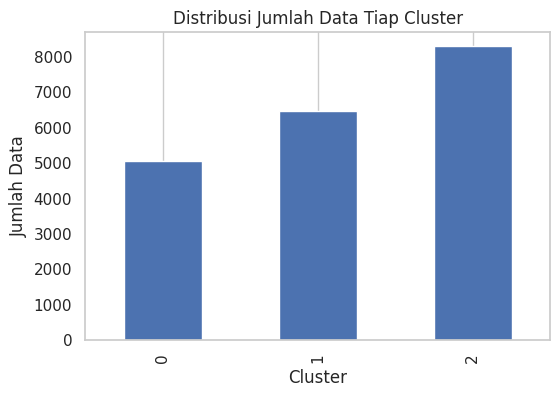

In [95]:
# ==========================================
# CELL 16.3 - Distribusi Cluster
# ==========================================

cluster_count = df_cluster["Cluster"].value_counts().sort_index()

print(cluster_count)

# Visualisasi
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

cluster_count.plot(
    kind="bar"
)

plt.title("Distribusi Jumlah Data Tiap Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.grid(axis='y')

plt.show()

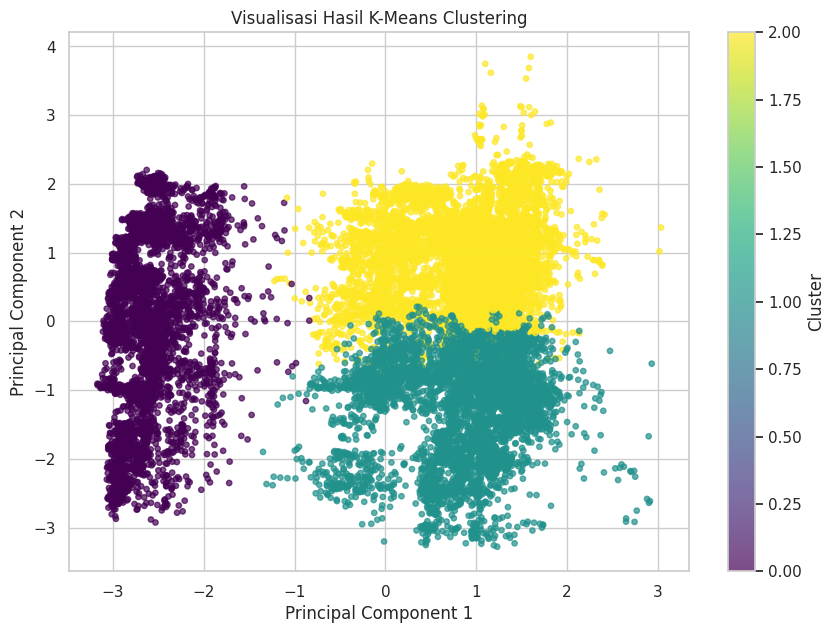

In [96]:
import matplotlib.pyplot as plt

# ==========================================
# CELL 16.4 - Visualisasi PCA
# ==========================================

plt.figure(figsize=(10,7))

plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    c=cluster_labels,
    cmap="viridis",
    s=15,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Visualisasi Hasil K-Means Clustering")

plt.colorbar(label="Cluster")

plt.grid(True)

plt.show()

In [97]:
# ==========================================
# CELL 16.5 - Statistik Tiap Cluster
# ==========================================

cluster_summary = df_cluster.groupby("Cluster").agg({

    "temp_mean":"mean",
    "rh_mean":"mean",
    "pd1_mean":"mean",
    "pd2_mean":"mean",
    "spectral_mean":"mean",
    "spectral_std":"mean",
    "pla_difference":"mean",
    "temp_rh_index":"mean"

}).round(2)

cluster_summary

,temp_mean,rh_mean,pd1_mean,pd2_mean,spectral_mean,spectral_std,pla_difference,temp_rh_index
Cluster,,,,,,,,
0,10.55,81.04,45.04,8.57,8998.64,18822.46,-18270.86,854.62
1,20.60,66.69,15660.35,3016.21,9553.03,18435.15,-18117.62,1371.59
2,20.22,66.08,15730.67,3074.64,8350.08,19162.36,-18297.48,1333.76


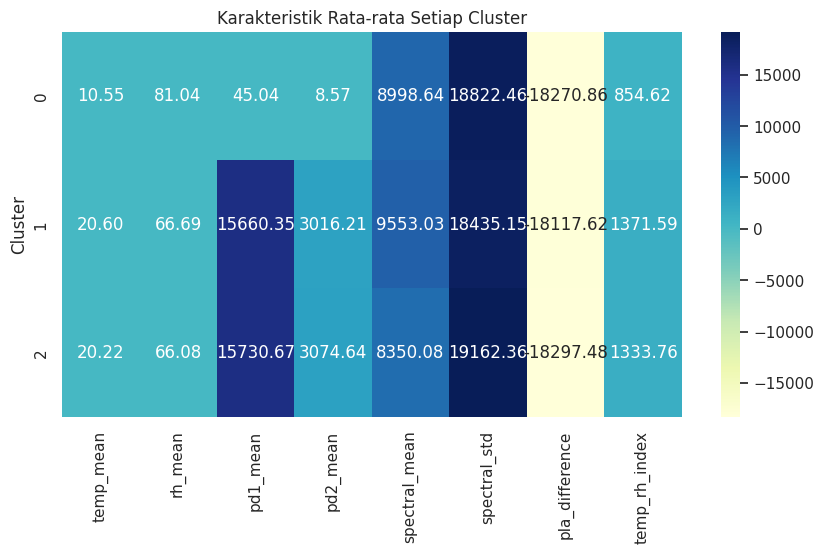

In [98]:
# ==========================================
# CELL 16.6 - Heatmap Cluster
# ==========================================

import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title("Karakteristik Rata-rata Setiap Cluster")

plt.show()

**CELL 17 — Analisis Mendalam Hasil Clustering**

In [99]:
# ==========================================
# CELL 17.1 - Cluster Centroid
# ==========================================

centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_selected.columns
)

centroids.index.name = "Cluster"

print("Centroid setiap cluster:")
display(centroids.round(3))

Centroid setiap cluster:


,temp_mean,rh_mean,pd1_mean,spectral_mean,spectral_std,pla_difference,rh_range
Cluster,,,,,,,
0,-1.287,1.478,-1.700,0.099,-0.031,-0.233,0.003
1,0.479,-0.460,0.578,0.704,-0.782,0.686,0.024
2,0.412,-0.543,0.588,-0.609,0.629,-0.393,-0.020


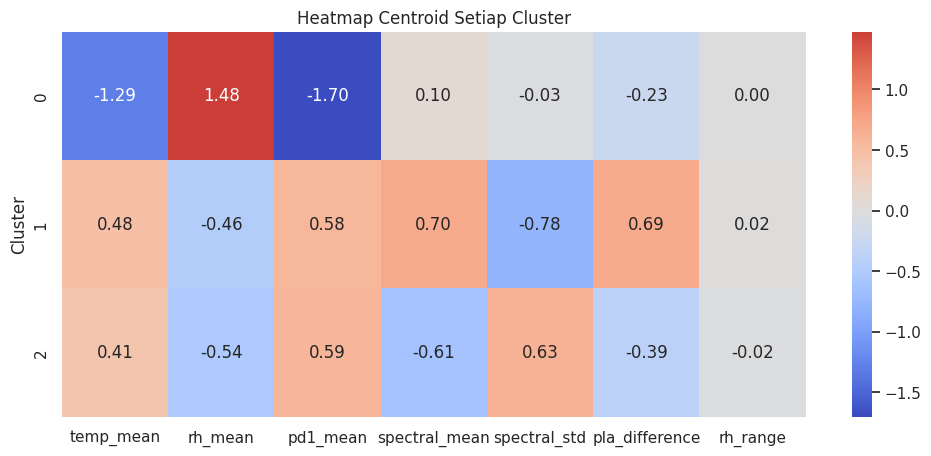

In [100]:
# ==========================================
# CELL 17.2 - Heatmap Centroid
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.heatmap(
    centroids,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Heatmap Centroid Setiap Cluster")

plt.show()

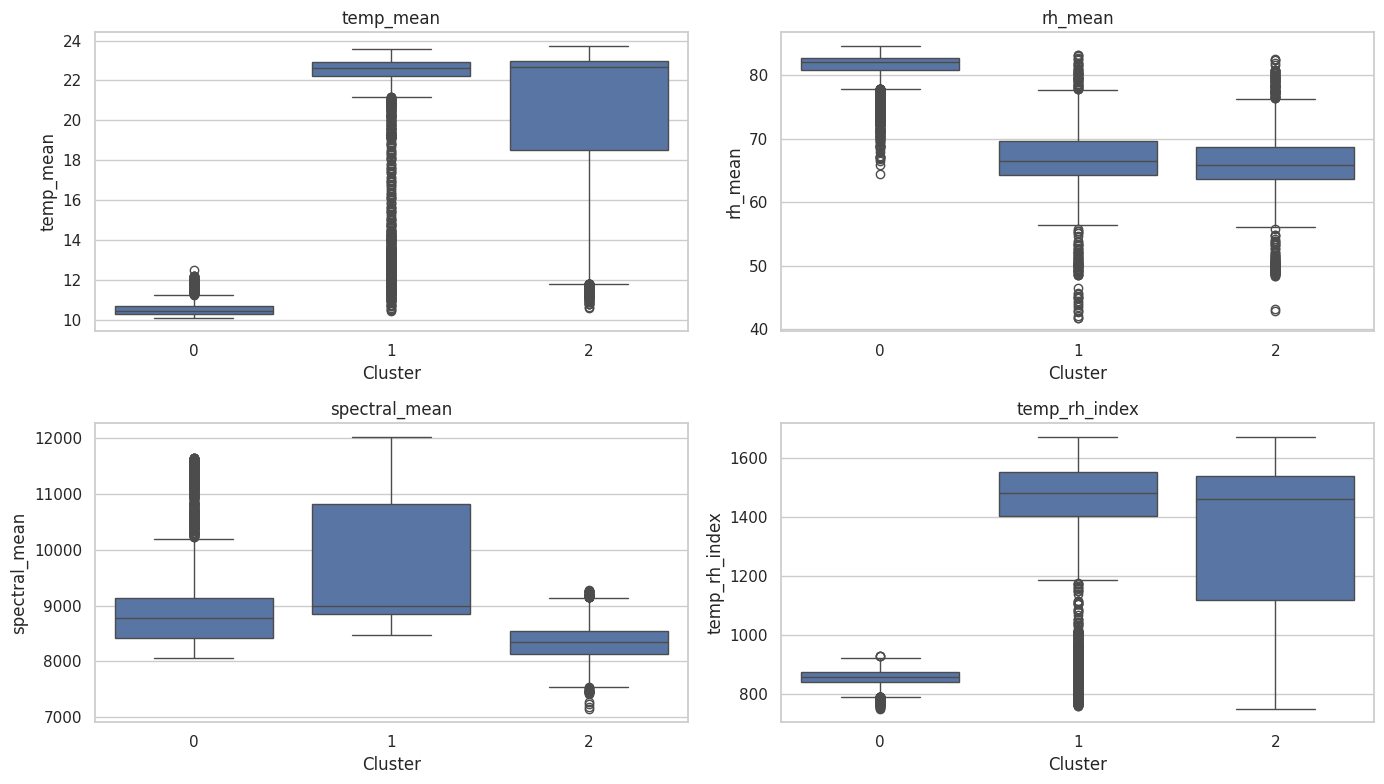

In [101]:
# ==========================================
# CELL 17.3 - Boxplot Feature
# ==========================================

features = [
    "temp_mean",
    "rh_mean",
    "spectral_mean",
    "temp_rh_index"
]

fig, axes = plt.subplots(2,2, figsize=(14,8))

axes = axes.flatten()

for i, feature in enumerate(features):

    sns.boxplot(
        data=df_cluster,
        x="Cluster",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()

plt.show()

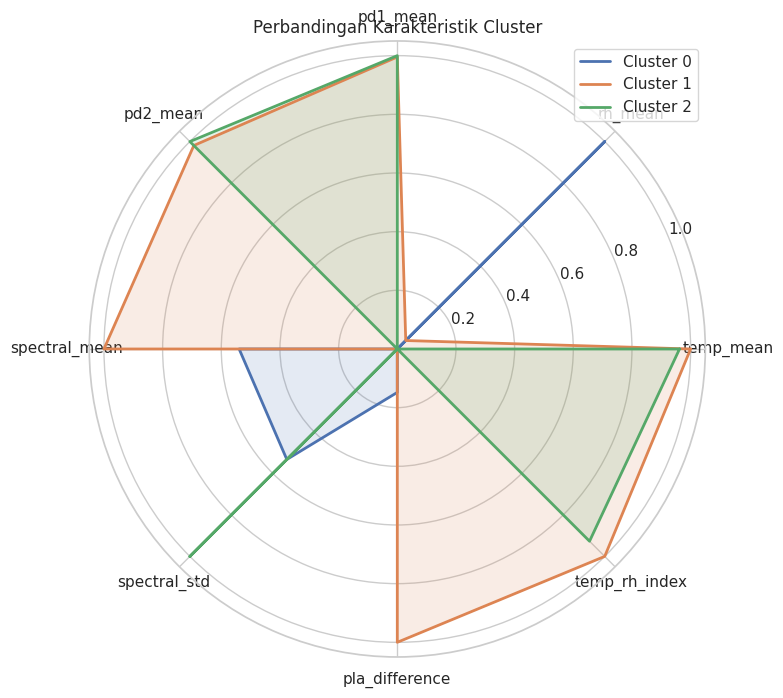

In [102]:
# ==========================================
# CELL 17.4 - Radar Chart
# ==========================================

from math import pi
from sklearn.preprocessing import MinMaxScaler

radar_feature = cluster_summary.copy()

scaler = MinMaxScaler()

radar_scaled = pd.DataFrame(
    scaler.fit_transform(radar_feature),
    columns=radar_feature.columns,
    index=radar_feature.index
)

categories = radar_scaled.columns.tolist()

N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]

angles += angles[:1]

plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

for idx in radar_scaled.index:

    values = radar_scaled.loc[idx].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=f"Cluster {idx}"
    )

    ax.fill(
        angles,
        values,
        alpha=0.15
    )

ax.set_xticks(angles[:-1])

ax.set_xticklabels(categories)

plt.title("Perbandingan Karakteristik Cluster")

plt.legend()

plt.show()

In [103]:
# ==========================================
# CELL 17.5 - Water Stress Score
# ==========================================

cluster_summary["Stress Score"] = (

    cluster_summary["temp_mean"]

    - cluster_summary["rh_mean"]

)

cluster_summary.sort_values(
    "Stress Score"
)

,temp_mean,rh_mean,pd1_mean,pd2_mean,spectral_mean,spectral_std,pla_difference,temp_rh_index,Stress Score
Cluster,,,,,,,,,
0,10.55,81.04,45.04,8.57,8998.64,18822.46,-18270.86,854.62,-70.49
1,20.60,66.69,15660.35,3016.21,9553.03,18435.15,-18117.62,1371.59,-46.09
2,20.22,66.08,15730.67,3074.64,8350.08,19162.36,-18297.48,1333.76,-45.86


In [104]:
cluster_mapping = {

    0 : "Optimal",

    2 : "Moderate Stress",

    1 : "High Stress"

}

df_cluster["Water_Stress"] = df_cluster["Cluster"].map(cluster_mapping)

df_cluster[
    ["Cluster","Water_Stress"]
].head()

,Cluster,Water_Stress
0,2,Moderate Stress
1,2,Moderate Stress
2,2,Moderate Stress
3,2,Moderate Stress
4,2,Moderate Stress


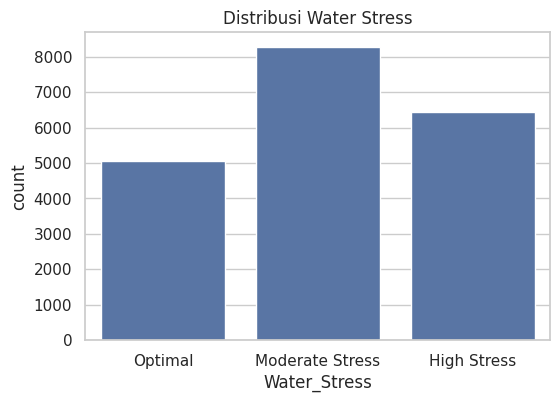

In [105]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_cluster,
    x="Water_Stress",
    order=[
        "Optimal",
        "Moderate Stress",
        "High Stress"
    ]
)

plt.title("Distribusi Water Stress")

plt.show()

**CELL 18 — Membuat Label Cluster**

In [106]:
# =====================================================
# CELL 18
# Memberikan Nama Pada Setiap Cluster
# =====================================================

cluster_mapping = {
    0: "Healthy Environment",
    1: "Optimal Growth",
    2: "Potential Water Stress"
}

df_cluster["Stress_Label"] = df_cluster["Cluster"].map(cluster_mapping)

df_cluster[["Cluster","Stress_Label"]].head()

,Cluster,Stress_Label
0,2,Potential Water Stress
1,2,Potential Water Stress
2,2,Potential Water Stress
3,2,Potential Water Stress
4,2,Potential Water Stress


Stress_Label
Potential Water Stress    8274
Optimal Growth            6446
Healthy Environment       5050
Name: count, dtype: int64


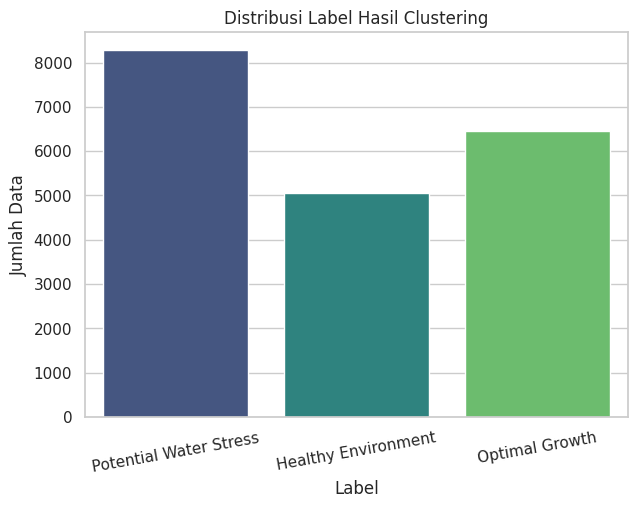

In [107]:
label_count = df_cluster["Stress_Label"].value_counts()

print(label_count)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_cluster,
    x="Stress_Label",
    palette="viridis"
)

plt.title("Distribusi Label Hasil Clustering")
plt.xlabel("Label")
plt.ylabel("Jumlah Data")

plt.xticks(rotation=10)

plt.show()

In [108]:
df_cluster.to_csv(
    "dataset_with_cluster_label.csv",
    index=False
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.


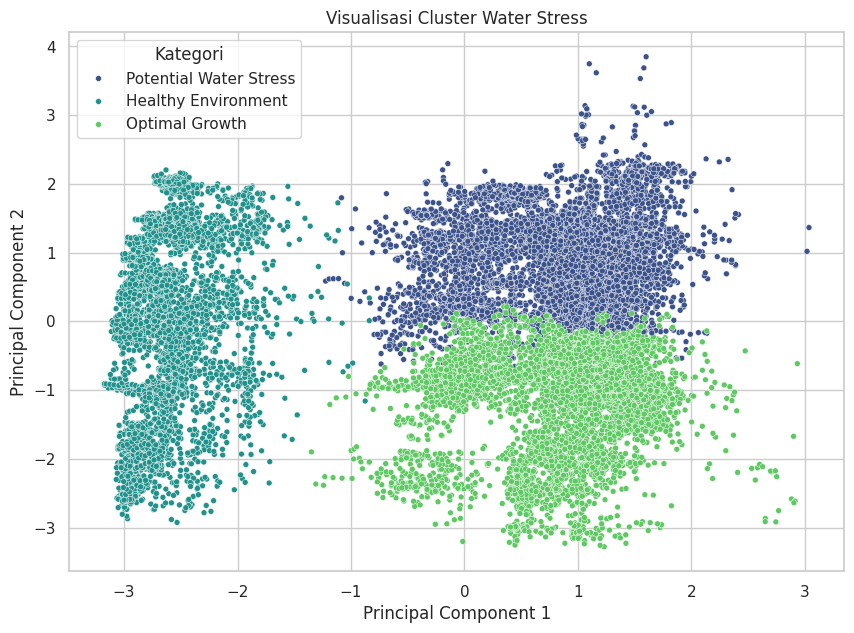

In [142]:
df_cluster["PCA1"] = X_pca["PC1"]
df_cluster["PCA2"] = X_pca["PC2"]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_cluster,
    x="PCA1",
    y="PCA2",
    hue="Stress_Label",
    palette="viridis",
    s=18
)

plt.title("Visualisasi Cluster Water Stress")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Kategori")

plt.show()

**CELL 19 — Membangun Model Prediksi Water Stress**

In [111]:
# ===========================================
# CELL 19.1
# Membuat Target Water Stress
# ===========================================

target_mapping = {
    0: "Low Stress",
    1: "Medium Stress",
    2: "High Stress"
}

df_cluster["Water_Stress"] = df_cluster["Cluster"].map(target_mapping)

df_cluster[["Cluster","Water_Stress"]].head()

,Cluster,Water_Stress
0,2,High Stress
1,2,High Stress
2,2,High Stress
3,2,High Stress
4,2,High Stress


In [112]:
df_cluster["Water_Stress"].value_counts()

,count
Water_Stress,
High Stress,8274
Medium Stress,6446
Low Stress,5050


In [113]:
feature_cols = [

    "temp_mean",
    "rh_mean",
    "pd1_mean",
    "pd2_mean",
    "spectral_mean",
    "spectral_std",
    "pla_difference",
    "temp_rh_index",
    "temp_range",
    "rh_range"

]

X = df_cluster[feature_cols]

y = df_cluster["Water_Stress"]

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(15816, 10)
(3954, 10)


In [115]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=300,
    random_state=42

)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [116]:
y_pred = rf.predict(X_test)

In [117]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)

print("Accuracy :",accuracy)

Accuracy : 0.9977238239757208


In [118]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

  High Stress       1.00      1.00      1.00      1655
   Low Stress       1.00      1.00      1.00      1010
Medium Stress       1.00      1.00      1.00      1289

     accuracy                           1.00      3954
    macro avg       1.00      1.00      1.00      3954
 weighted avg       1.00      1.00      1.00      3954



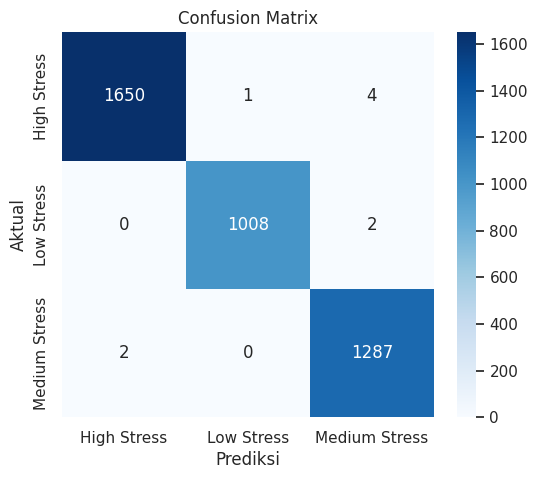

In [119]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=rf.classes_,

    yticklabels=rf.classes_

)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.title("Confusion Matrix")

plt.show()

CELL 19.9 Feature Importance ⭐⭐⭐

Ini nanti sangat bagus untuk laporan.

In [120]:
importance = pd.DataFrame({

    "Feature":feature_cols,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
4,spectral_mean,0.245606
2,pd1_mean,0.165527
3,pd2_mean,0.140148
6,pla_difference,0.138313
5,spectral_std,0.135808
0,temp_mean,0.090218
1,rh_mean,0.064541
7,temp_rh_index,0.017557
8,temp_range,0.001287
9,rh_range,0.000995


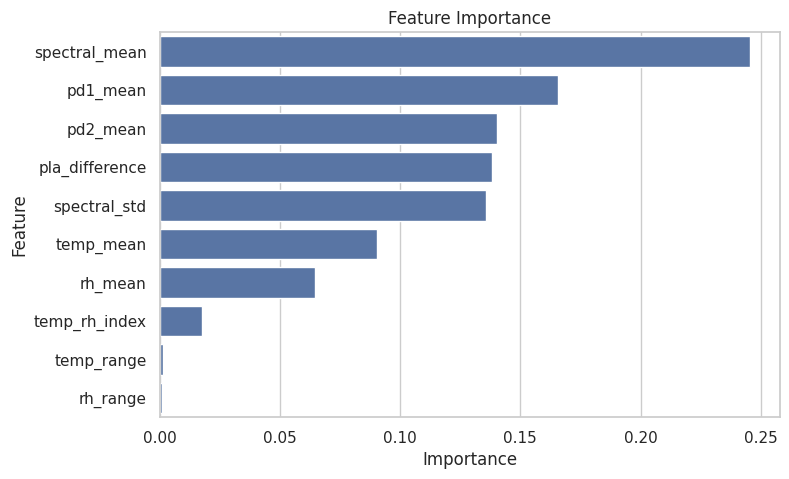

In [121]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

In [122]:
!pip install joblib

In [128]:
# ======================================================
# CELL 19
# Persiapan Dataset Random Forest
# ======================================================

# Feature yang akan digunakan
feature_columns = X_selected.columns.tolist()

X = df_cluster[feature_columns]

# Target berasal dari hasil clustering
y = df_cluster["Stress_Label"]

print("Jumlah Feature :", len(feature_columns))
print("Shape X :", X.shape)
print("Shape y :", y.shape)

print("\nDistribusi Label:")
print(y.value_counts())

Jumlah Feature : 7
Shape X : (19770, 7)
Shape y : (19770,)

Distribusi Label:
Stress_Label
Potential Water Stress    8274
Optimal Growth            6446
Healthy Environment       5050
Name: count, dtype: int64


CELL 20 — Train Test Split

In [129]:
# ======================================================
# CELL 20
# Train Test Split
# ======================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

print("Training :", X_train.shape)

print("Testing :", X_test.shape)

Training : (15816, 7)
Testing : (3954, 7)


In [130]:
# ======================================================
# CELL 21
# Training Random Forest
# ======================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(

    n_estimators=300,

    max_depth=15,

    min_samples_split=5,

    min_samples_leaf=2,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(

    X_train,

    y_train

)

print("Training selesai.")

Training selesai.


In [131]:
# ======================================================
# CELL 22
# Prediksi
# ======================================================

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)

print(y_pred[:10])

['Potential Water Stress' 'Potential Water Stress'
 'Potential Water Stress' 'Healthy Environment' 'Potential Water Stress'
 'Healthy Environment' 'Potential Water Stress' 'Potential Water Stress'
 'Optimal Growth' 'Healthy Environment']


In [132]:
# ======================================================
# CELL 23
# Evaluasi Model
# ======================================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(

    y_test,

    y_pred

)

print(f"Akurasi : {accuracy:.4f}")

Akurasi : 0.9987


In [133]:
# ======================================================
# CELL 24
# Classification Report
# ======================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        y_pred

    )

)

                        precision    recall  f1-score   support

   Healthy Environment       1.00      1.00      1.00      1010
        Optimal Growth       1.00      1.00      1.00      1289
Potential Water Stress       1.00      1.00      1.00      1655

              accuracy                           1.00      3954
             macro avg       1.00      1.00      1.00      3954
          weighted avg       1.00      1.00      1.00      3954



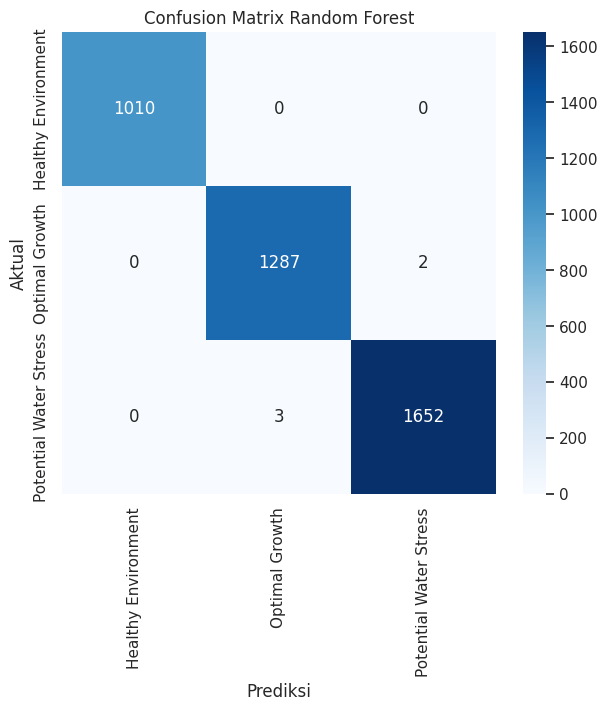

In [134]:
# ======================================================
# CELL 25
# Confusion Matrix
# ======================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    y_pred

)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    cmap="Blues",

    fmt="d",

    xticklabels=rf_model.classes_,

    yticklabels=rf_model.classes_

)

plt.xlabel("Prediksi")

plt.ylabel("Aktual")

plt.title("Confusion Matrix Random Forest")

plt.show()

In [135]:
# ======================================================
# CELL 26
# Feature Importance
# ======================================================

importance = pd.DataFrame({

    "Feature":feature_columns,

    "Importance":rf_model.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

display(importance)

,Feature,Importance
3,spectral_mean,0.223261
2,pd1_mean,0.198852
4,spectral_std,0.162846
0,temp_mean,0.155905
5,pla_difference,0.136817
1,rh_mean,0.120190
6,rh_range,0.002130


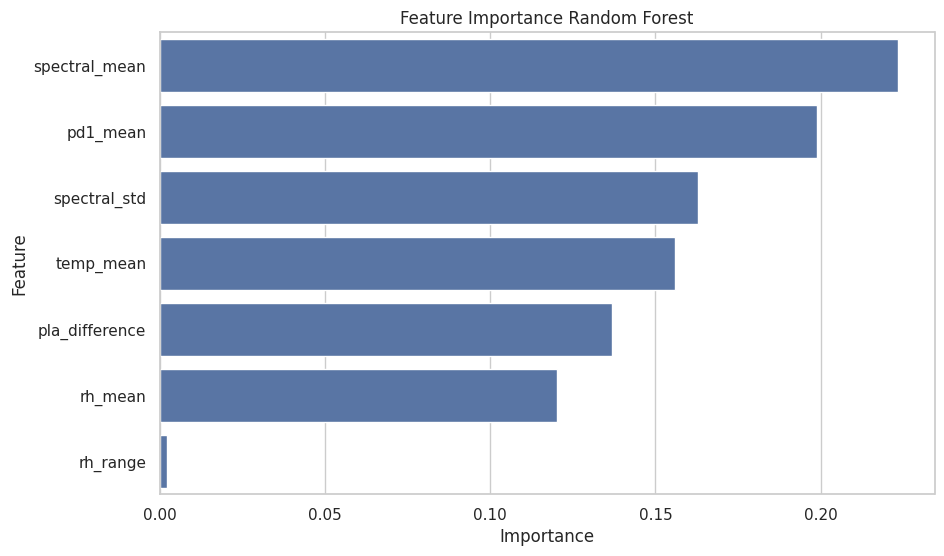

In [136]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    y="Feature",

    x="Importance"

)

plt.title("Feature Importance Random Forest")

plt.show()

lankah tambahan

In [144]:
import joblib

# Model Random Forest
joblib.dump(rf_model, "water_stress_model.pkl")

# Re-initialize and re-fit scaler on the final selected features
scaler = StandardScaler()
scaler.fit(X_selected)
joblib.dump(scaler, "standard_scaler.pkl")

# Re-initialize and re-fit PCA on the scaled final selected features
pca = PCA(n_components=2, random_state=42)
pca.fit(scaler.transform(X_selected)) # PCA is fit on scaled data
joblib.dump(pca, "pca_model.pkl")

# Feature List
feature_columns = X_selected.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

# Label Mapping
joblib.dump(cluster_mapping, "cluster_mapping.pkl")

print("Semua model berhasil disimpan.")

Semua model berhasil disimpan.


In [138]:
import os
import shutil

folder = "deployment_model"

os.makedirs(folder, exist_ok=True)

files = [
    "water_stress_model.pkl",
    "standard_scaler.pkl",
    "pca_model.pkl",
    "feature_columns.pkl",
    "cluster_mapping.pkl"
]

for f in files:
    shutil.copy(f, folder)

print("Deployment Folder berhasil dibuat.")

Deployment Folder berhasil dibuat.


CELL 29 — Load Model

Simulasi ketika backend Flask dijalankan.

In [139]:
import joblib

model = joblib.load("water_stress_model.pkl")

scaler = joblib.load("standard_scaler.pkl")

pca = joblib.load("pca_model.pkl")

feature_columns = joblib.load("feature_columns.pkl")

cluster_mapping = joblib.load("cluster_mapping.pkl")

CELL 30 — Fungsi Prediksi

Ini adalah fungsi yang nantinya dipanggil oleh website.

In [140]:
def predict_water_stress(input_df):
    """
    input_df harus memiliki kolom yang sama seperti feature_columns
    """

    # Pastikan urutan kolom sama
    input_df = input_df[feature_columns]

    # Scaling
    scaled = scaler.transform(input_df)

    # PCA
    pca_result = pca.transform(scaled)

    # Prediksi
    prediction = model.predict(input_df)

    probability = model.predict_proba(input_df)

    return prediction[0], probability.max()

CELL 31 — Simulasi Prediksi

Misalnya ambil satu data dari dataset.

In [145]:
sample = X.iloc[[100]]

label, confidence = predict_water_stress(sample)

print("Prediction :", label)

print("Confidence :", round(confidence*100,2),"%")

Prediction : Potential Water Stress
Confidence : 99.75 %
